In [10]:
import warnings
warnings.filterwarnings("ignore")

```{seealso}
Jupyter Book uses [Jupytext](https://jupytext.readthedocs.io/en/latest/) to convert text-based files to notebooks, and can support [many other text-based notebook files](https://jupyterbook.org/file-types/jupytext.html).
```


## Create a notebook with MyST Markdown

MyST Markdown notebooks are defined by two things:

1. YAML metadata that is needed to understand if / how it should convert text files to notebooks (including information about the kernel needed).
   See the YAML at the top of this page for example.
2. The presence of `{code-cell}` directives, which will be executed with your book.

That's all that is needed to get started!

## Quickly add YAML metadata for MyST Notebooks

If you have a markdown file and you'd like to quickly add YAML metadata to it, so that Jupyter Book will treat it as a MyST Markdown Notebook, run the following command:

```
jupyter-book myst init path/to/markdownfile.md
```

# Modelos No Supervisados

En el análisis del conjunto de datos de taxis de NYC, se exploran modelos no supervisados como K-means, DBSCAN y autoencoders para descubrir patrones inherentes y segmentar a los clientes sin depender de etiquetas predefinidas. K-means agrupa los viajes en clústeres basados en la proximidad de sus características, DBSCAN identifica clústeres densos y marca valores atípicos, y los autoencoders aprenden representaciones comprimidas de los datos para revelar estructuras subyacentes. Estas técnicas permiten identificar segmentos de clientes con comportamientos similares, optimizar servicios y mejorar la segmentación de marketing.

## Kmeans

Este código implementa el algoritmo de clustering K-means para segmentar datos de viajes de taxi, buscando patrones inherentes sin etiquetas predefinidas. Primero, selecciona columnas numéricas relevantes y las estandariza para asegurar que todas contribuyan equitativamente al cálculo de distancias. Luego, aplica el "método del codo" para determinar el número óptimo de clústeres, graficando la inercia (suma de distancias cuadradas) para diferentes valores de 'k'. Finalmente, entrena K-means con el número óptimo de clústeres encontrado y asigna cada viaje a un clúster, añadiendo esta información al DataFrame original para su posterior análisis y visualización.

In [2]:
import pickle

with open('taxi_df.pkl', 'rb') as f:
    taxi_df = pickle.load(f)


In [3]:
# seleccion de variabls
print(taxi_df.columns)

Index(['PULocationID', 'DOLocationID', 'Passengers', 'Distance', 'RatecodeID',
       'fare_amount', 'total_amount', 'PickUpYear', 'PickUpMonth',
       'PickUpWeek', 'PickUpDay', 'PickUpHour', 'PickUpDayWeek',
       'payment_type', 'tolls_amount', 'Duration', 'Zone_pickup',
       'Zone_dropoff', 'Duration_seconds', 'Duration_minutes',
       'Duration_range', 'Amount_range'],
      dtype='object')


In [4]:
# DataFrame con las variables seleccionadas para los modelos de clustering
variables_clustering = [
    'total_amount',
    'Distance',
    'Passengers',
    'tolls_amount',
    'Duration_seconds',
    'payment_type',
    'RatecodeID'
]

# Crear una copia con solo esas columnas
df_clustering = taxi_df[variables_clustering].copy()

# Mostrar las primeras filas
df_clustering.head()

,total_amount,Distance,Passengers,tolls_amount,Duration_seconds,payment_type,RatecodeID
0,9.95,1.5,1.0,0.0,400.0,1,1.0
1,16.30,2.6,1.0,0.0,1152.0,1,1.0
7,9.05,1.3,1.0,0.0,429.0,1,1.0
8,18.50,3.7,1.0,0.0,818.0,1,1.0
9,13.00,2.1,2.0,0.0,720.0,1,1.0


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn_extra.cluster import KMedoids
import pickle
from tqdm import tqdm
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample

In [6]:
# Variables
numeric_features = ['Distance', 'Passengers', 'tolls_amount', 'Duration_seconds', 'total_amount']
categorical_features = ['payment_type', 'RatecodeID']
# Preprocesador

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [7]:
X = df_clustering[numeric_features + categorical_features]
X_transf = preprocessor.fit_transform(X)

In [8]:
X_sample = resample(X_transf, n_samples=150000, random_state=42)

## GridSearchCV incorporando el Davies-Bouldin

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import time
import numpy as np

# Suponiendo que tienes X_sample definido

# Definir el rango de parámetros para el ajuste
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [300, 400, 500]
}

# Definir el modelo KMeans
kmeans = KMeans(random_state=42, n_init='auto')

# Definir una función de scoring para Davies-Bouldin (negativo)
def negative_davies_bouldin(estimator, X):
    labels = estimator.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    return -score

# Realizar la búsqueda de hiperparámetros
grid_search = GridSearchCV(kmeans, param_grid, cv=3, scoring=negative_davies_bouldin)

print("Comenzando la búsqueda de hiperparámetros...")

results = []

grid_search.fit(X_sample) # Ajustar GridSearchCV

for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_neg_db = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_neg_db, duration))
    print(f"Parámetros: {params}, Score Promedio (neg_Davies-Bouldin): {mean_neg_db:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\nTodos los resultados de la búsqueda:")
for params, score, duration in results:
    print(f"Parámetros: {params}, Score Promedio (neg_Davies-Bouldin): {score:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar el mejor conjunto de hiperparámetros
print("\nMejores parámetros: ", grid_search.best_params_)


Comenzando la búsqueda de hiperparámetros...
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2}, Score Promedio (neg_Davies-Bouldin): -0.5514, Tiempo: 0.04 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3}, Score Promedio (neg_Davies-Bouldin): -0.6333, Tiempo: 0.05 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4}, Score Promedio (neg_Davies-Bouldin): -0.6586, Tiempo: 0.05 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5}, Score Promedio (neg_Davies-Bouldin): -0.6913, Tiempo: 0.06 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6}, Score Promedio (neg_Davies-Bouldin): -0.7532, Tiempo: 0.06 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_clusters': 2}, Score Promedio (neg_Davies-Bouldin): -0.5514, Tiempo: 0.04 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_clusters': 3}, Score Promedio (neg_Davies-Bouldin): -0.6333, Tiempo: 0.05 segun

### Implementacion K-Means (Davies-Bouldin)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Crear el modelo con los mejores parámetros encontrados por MSE
kmeans_davies = KMeans(n_clusters=2, init='k-means++', max_iter=300, random_state=42)

# Entrenar el modelo
kmeans_davies.fit(X_sample)

# Obtener las etiquetas del modelo basado en MSE
labels_davies = kmeans_davies.labels_

# Calcular métricas
silhouette_mse = silhouette_score(X_sample, labels_davies)
davies_bouldin_mse = davies_bouldin_score(X_sample, labels_davies)
calinski_harabasz_mse = calinski_harabasz_score(X_sample, labels_davies)

# Imprimir resultados
print(f"Silhouette Score (MSE): {silhouette_mse:.4f}")
print(f"Davies-Bouldin Score (MSE): {davies_bouldin_mse:.4f}")
print(f"Calinski-Harabasz Score (MSE): {calinski_harabasz_mse:.4f}")

Silhouette Score (MSE): 0.7129
Davies-Bouldin Score (MSE): 0.7252
Calinski-Harabasz Score (MSE): 86988.6291


## GridSearchCV incorporando el Silhouette

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# Suponiendo que tienes X_sample definido

# Definir el rango de parámetros para el ajuste
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [300, 400, 500]
}

# Definir el modelo base
kmeans = KMeans(random_state=42, n_init='auto')

# Función de scoring personalizada para Silhouette
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=kmeans,
    param_grid=param_grid,
    scoring=silhouette_scorer,
    cv=3,
    verbose=1,  # Esto muestra el progreso en consola
    n_jobs=-1   # Usa todos los núcleos disponibles
)

print(" Comenzando la búsqueda de hiperparámetros...\n")
grid_search.fit(X_sample)

# Mostrar mejores parámetros
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

# -------------------------------------------
#  Mostrar tabla completa de resultados
# -------------------------------------------
print("\n Resultados completos ordenados por mejor score:\n")

# Crear DataFrame con resultados
results_df = pd.DataFrame(grid_search.cv_results_)

# Seleccionar columnas útiles
columns_to_show = ['params', 'mean_test_score', 'std_test_score', 'mean_fit_time', 'mean_score_time']
results_df = results_df[columns_to_show]

# Ordenar por mayor Silhouette Score
results_df_sorted = results_df.sort_values(by='mean_test_score', ascending=False)

# Mostrar todo
pd.set_option('display.max_rows', None)  # Mostrar todas las filas
print(results_df_sorted)


 Comenzando la búsqueda de hiperparámetros...

Fitting 3 folds for each of 30 candidates, totalling 90 fits

 Mejores parámetros encontrados:
{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2}

 Resultados completos ordenados por mejor score:

                                               params  mean_test_score  \
0   {'init': 'k-means++', 'max_iter': 300, 'n_clus...         0.769978   
5   {'init': 'k-means++', 'max_iter': 400, 'n_clus...         0.769978   
10  {'init': 'k-means++', 'max_iter': 500, 'n_clus...         0.769978   
25  {'init': 'random', 'max_iter': 500, 'n_cluster...         0.712788   
20  {'init': 'random', 'max_iter': 400, 'n_cluster...         0.712788   
15  {'init': 'random', 'max_iter': 300, 'n_cluster...         0.712788   
6   {'init': 'k-means++', 'max_iter': 400, 'n_clus...         0.658873   
11  {'init': 'k-means++', 'max_iter': 500, 'n_clus...         0.658873   
1   {'init': 'k-means++', 'max_iter': 300, 'n_clus...         0.658873   
3   {'init'

### Implementacion K-Means (Silhouette)

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Extraer mejores parámetros desde grid_search
best_params = grid_search.best_params_

# Crear el modelo con los mejores parámetros
kmeans_silhouette = KMeans(
    n_clusters=best_params['n_clusters'],
    init=best_params['init'],
    max_iter=best_params['max_iter'],
    random_state=42,
    n_init='auto'
)

# Entrenar el modelo
kmeans_silhouette.fit(X_sample)

# Obtener las etiquetas del modelo
labels_silhouette = kmeans_silhouette.labels_

# Calcular métricas
silhouette_final = silhouette_score(X_sample, labels_silhouette)
davies_bouldin_final = davies_bouldin_score(X_sample, labels_silhouette)
calinski_harabasz_final = calinski_harabasz_score(X_sample, labels_silhouette)

# Imprimir resultados
print(f"Silhouette Score (final): {silhouette_final:.4f}")
print(f"Davies-Bouldin Score (final): {davies_bouldin_final:.4f}")
print(f"Calinski-Harabasz Score (final): {calinski_harabasz_final:.4f}")

Silhouette Score (final): 0.7129
Davies-Bouldin Score (final): 0.7252
Calinski-Harabasz Score (final): 86988.6291


## GridSearchCV incorporando Calinski-Harabasz

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
import numpy as np

# Definir el rango de parámetros para el ajuste
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'init': ['k-means++', 'random'],
    'max_iter': [300, 400, 500]
}

# Definir el modelo KMeans
kmeans = KMeans(random_state=42, n_init='auto')

# Definir función de scoring con Calinski-Harabasz
def calinski_harabasz_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    score = calinski_harabasz_score(X, labels)
    return score  # Se maximiza

# Realizar la búsqueda de hiperparámetros con uso de todos los núcleos
grid_search = GridSearchCV(
    estimator=kmeans,
    param_grid=param_grid,
    cv=3,
    scoring=calinski_harabasz_scorer,
    n_jobs=-1,  # Usa todos los núcleos disponibles
    verbose=2   # Opcional: para ver qué está haciendo en tiempo real
)

print("Comenzando la búsqueda de hiperparámetros...")

results = []

grid_search.fit(X_sample)  # Ajustar GridSearchCV

for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_ch = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_ch, duration))
    print(f"Parámetros: {params}, Score Promedio (Calinski-Harabasz): {mean_ch:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\nTodos los resultados de la búsqueda:")
for params, score, duration in results:
    print(f"Parámetros: {params}, Score Promedio (Calinski-Harabasz): {score:.4f}, Tiempo: {duration:.2f} segundos")

# Mostrar el mejor conjunto de hiperparámetros
print("\nMejores parámetros: ", grid_search.best_params_)



Comenzando la búsqueda de hiperparámetros...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2}, Score Promedio (Calinski-Harabasz): 22655.3701, Tiempo: 0.21 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3}, Score Promedio (Calinski-Harabasz): 28406.8834, Tiempo: 0.32 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 4}, Score Promedio (Calinski-Harabasz): 32103.1283, Tiempo: 0.26 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 5}, Score Promedio (Calinski-Harabasz): 36640.7579, Tiempo: 0.39 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 6}, Score Promedio (Calinski-Harabasz): 39394.7964, Tiempo: 0.48 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_clusters': 2}, Score Promedio (Calinski-Harabasz): 22655.3701, Tiempo: 0.19 segundos
Parámetros: {'init': 'k-means++', 'max_iter': 400, 'n_cluste

### Implementacion K-Means (Calinski-Harabasz)

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Extraer los mejores parámetros del grid search
best_params_ch = grid_search.best_params_

# Crear el modelo con los mejores parámetros
kmeans_ch = KMeans(
    n_clusters=best_params_ch['n_clusters'],
    init=best_params_ch['init'],
    max_iter=best_params_ch['max_iter'],
    random_state=42,
    n_init='auto'
)

# Entrenar el modelo
kmeans_ch.fit(X_sample)

# Obtener las etiquetas del modelo
labels_ch = kmeans_ch.labels_

# Calcular las métricas
silhouette_ch = silhouette_score(X_sample, labels_ch)
davies_bouldin_ch = davies_bouldin_score(X_sample, labels_ch)
calinski_harabasz_ch = calinski_harabasz_score(X_sample, labels_ch)

# Mostrar métricas
print(f"Silhouette Score (CH): {silhouette_ch:.4f}")
print(f"Davies-Bouldin Score (CH): {davies_bouldin_ch:.4f}")
print(f"Calinski-Harabasz Score (CH): {calinski_harabasz_ch:.4f}")


Silhouette Score (CH): 0.5121
Davies-Bouldin Score (CH): 0.6943
Calinski-Harabasz Score (CH): 125011.9021


## GRÁFICAS

**Gráfica** Davies-Bouldin

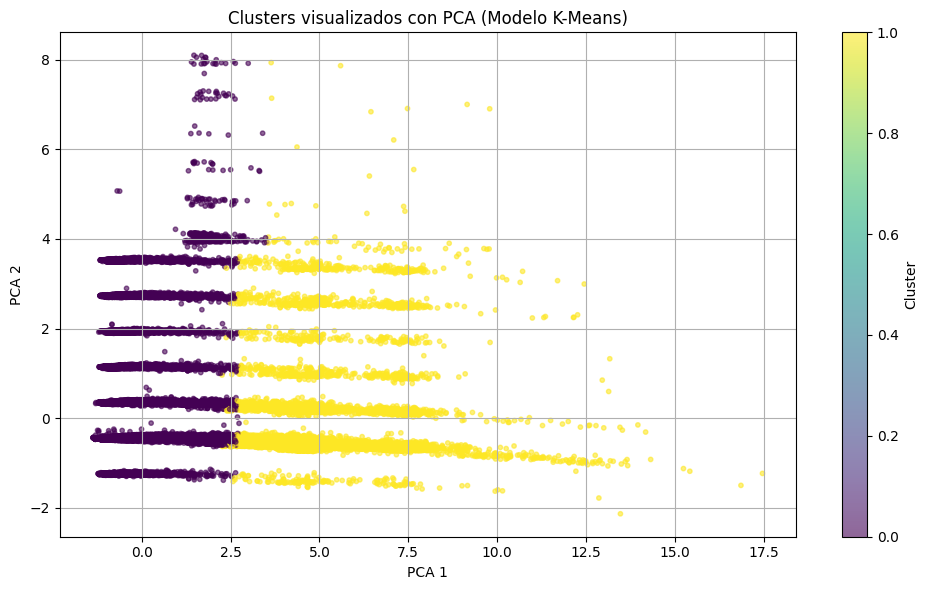

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Usar las etiquetas del modelo ya entrenado
labels = kmeans_davies.labels_

# Graficar los clusters en el nuevo espacio reducido
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters visualizados con PCA (Modelo K-Means)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


**Gráfica** Silhouette

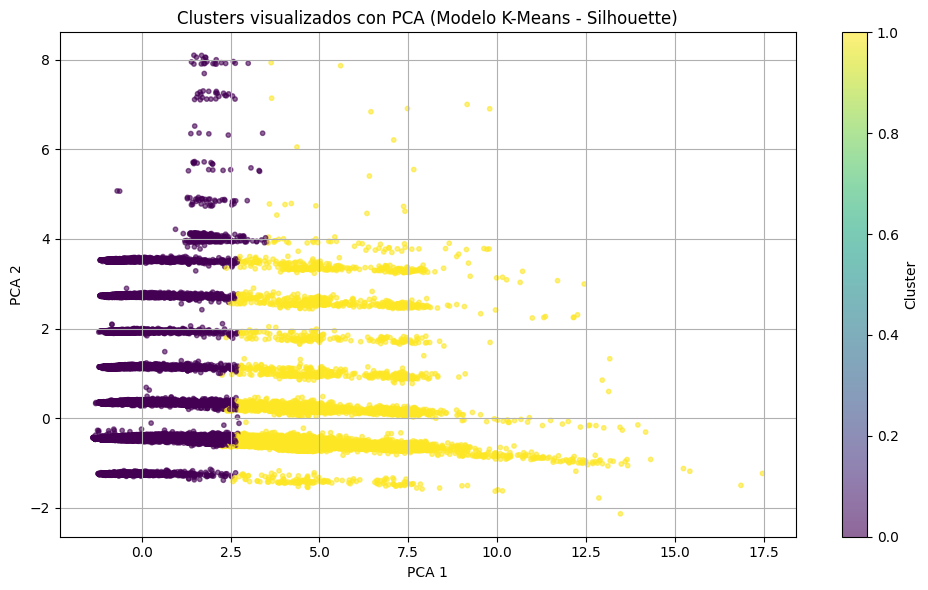

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir dimensionalidad con PCA
pca = PCA(n_components=2)
X_pca_silhouette = pca.fit_transform(X_sample)

# Graficar clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_silhouette[:, 0], X_pca_silhouette[:, 1],
            c=labels_silhouette, cmap='viridis', s=10, alpha=0.6)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters visualizados con PCA (Modelo K-Means - Silhouette)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


**Gráfica** Calinski-Harabasz

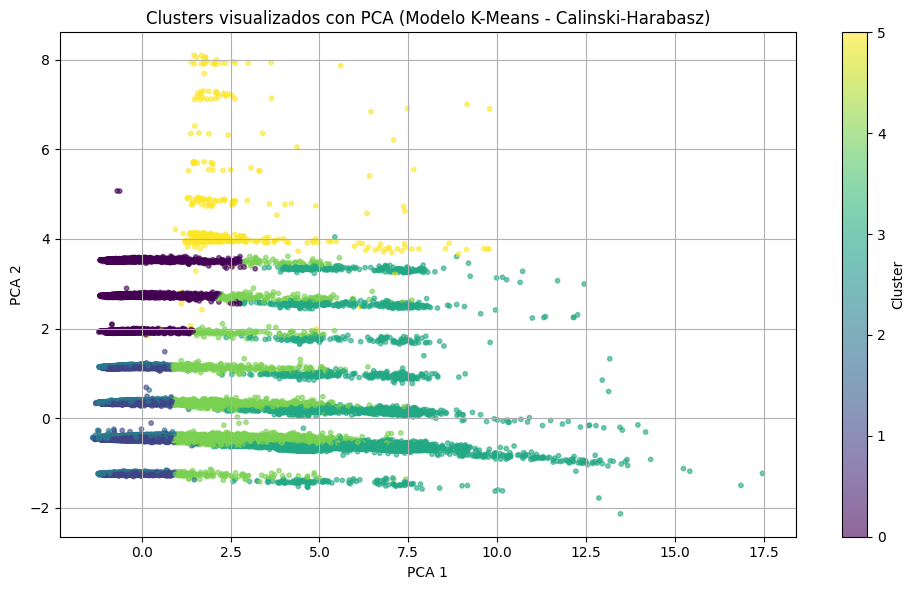

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicar PCA a los datos
pca = PCA(n_components=2)
X_pca_ch = pca.fit_transform(X_sample)

# Graficar los clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_ch[:, 0], X_pca_ch[:, 1], c=labels_ch, cmap='viridis', s=10, alpha=0.6)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters visualizados con PCA (Modelo K-Means - Calinski-Harabasz)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


GRAFICAS TOTAL

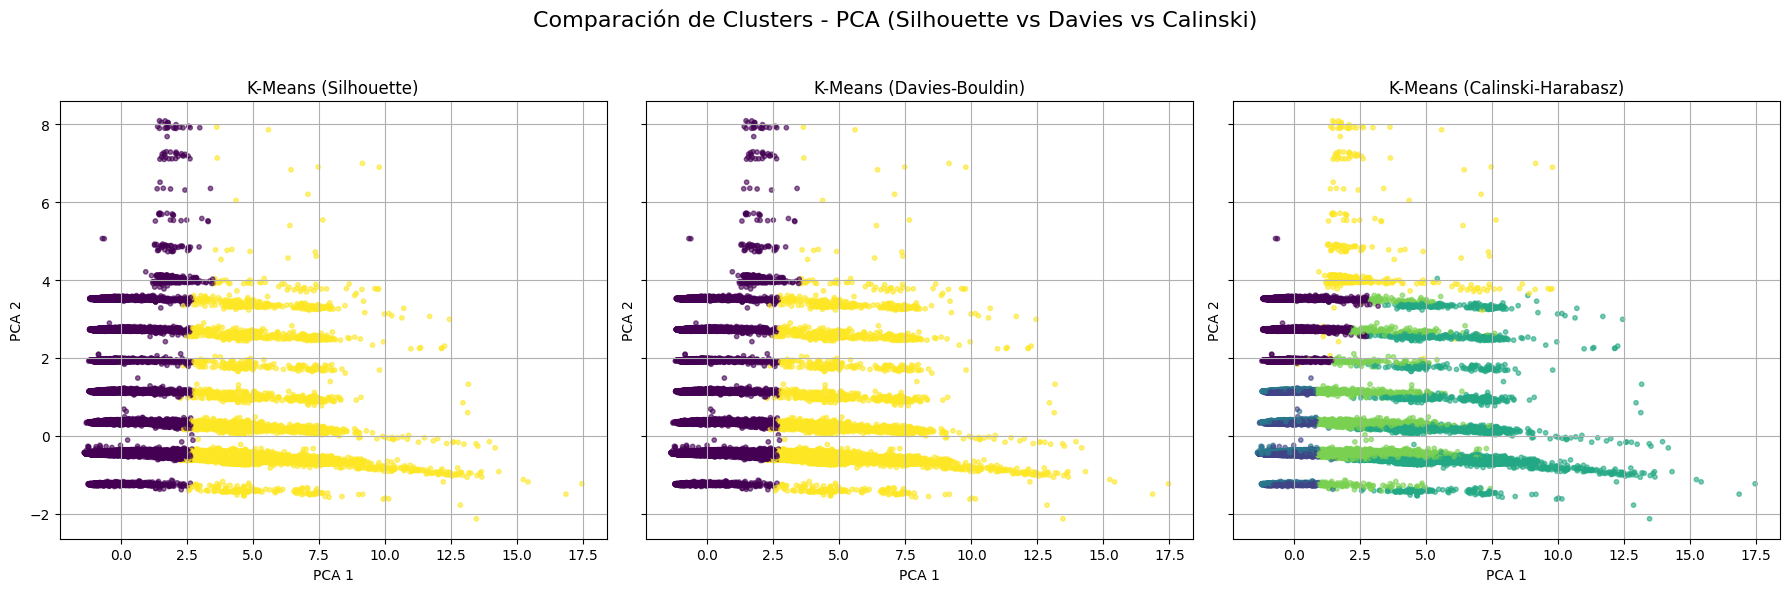

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Aplicamos PCA solo una vez a X_sample (mismo espacio para todos)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Diccionario con los modelos y etiquetas
modelos = {
    'Silhouette': kmeans_silhouette.labels_,
    'Davies-Bouldin': kmeans_davies.labels_,
    'Calinski-Harabasz': kmeans_ch.labels_
}

# Crear figura con 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

# Recorrer los modelos y graficarlos en subplots
for i, (titulo, labels) in enumerate(modelos.items()):
    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
    axs[i].set_title(f'K-Means ({titulo})')
    axs[i].set_xlabel('PCA 1')
    axs[i].set_ylabel('PCA 2')
    axs[i].grid(True)

plt.suptitle('Comparación de Clusters - PCA (Silhouette vs Davies vs Calinski)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold
import numpy as np
import time
from tqdm import tqdm

# Suponiendo que ya tenés X_sample (tus datos ya escalados o preprocesados)
# Por ejemplo:
# from sklearn.datasets import make_moons
# from sklearn.preprocessing import StandardScaler
# X_sample, _ = make_moons(n_samples=500, noise=0.05)
# X_sample = StandardScaler().fit_transform(X_sample)

# Definir el rango de parámetros para DBSCAN
param_grid_dbscan = [
    {'eps': eps, 'min_samples': min_samples}
    for eps in np.arange(0.1, 1.0, 0.1)
    for min_samples in range(5, 50, 5)
]

# Objeto para dividir los datos en 3 folds
kf = KFold(n_splits=3, shuffle=True, random_state=42)

results_dbscan = []

print(" Comenzando la búsqueda de hiperparámetros para DBSCAN...\n")
for params in tqdm(param_grid_dbscan, desc="Buscando"):
    scores = []
    fit_times = []
    score_times = []

    for train_index, val_index in kf.split(X_sample):
        X_train, X_val = X_sample[train_index], X_sample[val_index]
        
        start_fit = time.time()
        dbscan_temp = DBSCAN(**params)
        labels_train = dbscan_temp.fit_predict(X_train)
        fit_times.append(time.time() - start_fit)

        start_score = time.time()
        score = -1
        if len(np.unique(labels_train)) > 1:
            labels_val = dbscan_temp.fit_predict(X_val)
            if len(np.unique(labels_val)) > 1:
                score = silhouette_score(X_val, labels_val)
        scores.append(score)
        score_times.append(time.time() - start_score)

    mean_silhouette = np.mean(scores)
    mean_fit_time = np.mean(fit_times)
    mean_score_time = np.mean(score_times)
    duration = mean_fit_time + mean_score_time

    results_dbscan.append((params, mean_silhouette, duration))
    tqdm.write(f"Parámetros: {params}, Silhouette Score Promedio: {mean_silhouette:.4f}, Tiempo total: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\n Resultados de la búsqueda:")
for params, score, duration in results_dbscan:
    print(f"Parámetros: {params}, Silhouette Score Promedio: {score:.4f}, Tiempo: {duration:.2f} s")

# Obtener los mejores parámetros
best_result = max(results_dbscan, key=lambda x: x[1])
best_params_dbscan = best_result[0]
best_score_dbscan = best_result[1]

print("\n Mejores parámetros encontrados para DBSCAN:")
print(f"Parámetros: {best_params_dbscan}")
print(f" Mejor Silhouette Score: {best_score_dbscan:.4f}")




🔍 Comenzando la búsqueda de hiperparámetros para DBSCAN...



Buscando:   1%|          | 1/81 [02:17<3:03:33, 137.66s/it]

Parámetros: {'eps': 0.1, 'min_samples': 5}, Silhouette Score Promedio: 0.2037, Tiempo total: 45.88 segundos


Buscando:   2%|▏         | 2/81 [04:40<3:05:06, 140.59s/it]

Parámetros: {'eps': 0.1, 'min_samples': 10}, Silhouette Score Promedio: 0.2618, Tiempo total: 47.54 segundos


...

Parámetros: {'eps': 0.9, 'min_samples': 35}, Silhouette Score Promedio: 0.2815, Tiempo total: 137.59 segundos


Buscando:  99%|█████████▉| 80/81 [5:27:16<06:42, 402.95s/it]

Parámetros: {'eps': 0.9, 'min_samples': 40}, Silhouette Score Promedio: 0.2781, Tiempo total: 136.91 segundos


Buscando: 100%|██████████| 81/81 [5:34:03<00:00, 247.45s/it]

Parámetros: {'eps': 0.9, 'min_samples': 45}, Silhouette Score Promedio: 0.2819, Tiempo total: 135.65 segundos

📊 Resultados de la búsqueda:
Parámetros: {'eps': 0.1, 'min_samples': 5}, Silhouette Score Promedio: 0.2037, Tiempo: 45.88 s
Parámetros: {'eps': 0.1, 'min_samples': 10}, Silhouette Score Promedio: 0.2618, Tiempo: 47.54 s
Parámetros: {'eps': 0.1, 'min_samples': 15}, Silhouette Score Promedio: 0.2622, Tiempo: 47.68 s
Parámetros: {'eps': 0.1, 'min_samples': 20}, Silhouette Score Promedio: 0.2805, Tiempo: 47.38 s
Parámetros: {'eps': 0.1, 'min_samples': 25}, Silhouette Score Promedio: 0.2889, Tiempo: 46.67 s
Parámetros: {'eps': 0.1, 'min_samples': 30}, Silhouette Score Promedio: 0.2600, Tiempo: 46.00 s
Parámetros: {'eps': 0.1, 'min_samples': 35}, Silhouette Score Promedio: 0.3026, Tiempo: 45.63 s
Parámetros: {'eps': 0.1, 'min_samples': 40}, Silhouette Score Promedio: 0.3185, Tiempo: 45.67 s
Parámetros: {'eps': 0.1, 'min_samples': 45}, Silhouette Score Promedio: 0.3252, Tiempo: 45.11

### Implementacion DBSCAN

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample


# Mejores hiperparámetros
best_eps = 0.8
best_min_samples = 5

# Ajustar el modelo final en el subconjunto
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_final = dbscan_final.fit_predict(X_sample)

# Calcular métricas si hay más de un cluster
if len(set(labels_final)) > 1:
    silhouette = silhouette_score(X_sample, labels_final)
    davies_bouldin = davies_bouldin_score(X_sample, labels_final)
    calinski_harabasz = calinski_harabasz_score(X_sample, labels_final)

    print(f" Métricas del modelo final DBSCAN (sobre muestra):")
    print(f"• Silhouette Score: {silhouette:.4f}")
    print(f"• Davies-Bouldin Score: {davies_bouldin:.4f}")
    print(f"• Calinski-Harabasz Score: {calinski_harabasz:.4f}")
else:
    print(" No se pueden calcular las métricas porque DBSCAN no formó más de un cluster válido.")

**Gráfica DBSCAN**

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Aplicar PCA para reducir a 2 dimensiones solo para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# Visualizar los clusters con colores según etiquetas de DBSCAN
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels_final, cmap='viridis', s=60, alpha=0.7, edgecolors='k')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters visualizados con PCA (DBSCAN)')
plt.colorbar(scatter, label='Etiqueta de Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


DAVIES

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score
from sklearn.model_selection import KFold
import numpy as np
import time
from tqdm import tqdm

# Supone que X_sample ya está definido (escalado y listo para usar)

# Definir el rango de parámetros para DBSCAN
param_grid_dbscan = [
    {'eps': eps, 'min_samples': min_samples}
    for eps in np.arange(0.1, 1.0, 0.1)
    for min_samples in range(5, 50, 5)
]

# Objeto para dividir los datos en 3 folds
kf = KFold(n_splits=3, shuffle=True, random_state=42)

results_dbscan = []

print(" Comenzando la búsqueda de hiperparámetros para DBSCAN con Davies-Bouldin...\n")
for params in tqdm(param_grid_dbscan, desc="Buscando"):
    scores = []
    fit_times = []
    score_times = []

    for train_index, val_index in kf.split(X_sample):
        X_train, X_val = X_sample[train_index], X_sample[val_index]

        start_fit = time.time()
        dbscan_temp = DBSCAN(**params)
        labels_train = dbscan_temp.fit_predict(X_train)
        fit_times.append(time.time() - start_fit)

        start_score = time.time()
        score = np.inf  # Davies-Bouldin se minimiza
        if len(np.unique(labels_train)) > 1:
            labels_val = dbscan_temp.fit_predict(X_val)
            if len(np.unique(labels_val)) > 1:
                score = davies_bouldin_score(X_val, labels_val)
        scores.append(score)
        score_times.append(time.time() - start_score)

    mean_db = np.mean(scores)
    mean_fit_time = np.mean(fit_times)
    mean_score_time = np.mean(score_times)
    duration = mean_fit_time + mean_score_time

    results_dbscan.append((params, mean_db, duration))
    tqdm.write(f"Parámetros: {params}, DB Score Promedio: {mean_db:.4f}, Tiempo total: {duration:.2f} segundos")

# Mostrar todos los resultados
print("\n Resultados de la búsqueda:")
for params, score, duration in results_dbscan:
    print(f"Parámetros: {params}, DB Score Promedio: {score:.4f}, Tiempo: {duration:.2f} s")

# Obtener los mejores parámetros (mínimo DB)
best_result = min(results_dbscan, key=lambda x: x[1])
best_params_dbscan = best_result[0]
best_score_dbscan = best_result[1]

print("\n Mejores parámetros encontrados para DBSCAN:")
print(f"Parámetros: {best_params_dbscan}")
print(f"Mejor Davies-Bouldin Score: {best_score_dbscan:.4f}")


🌀 Comenzando la búsqueda de hiperparámetros para DBSCAN con Davies-Bouldin...



Buscando:   1%|          | 1/81 [01:19<1:45:36, 79.20s/it]

Parámetros: {'eps': 0.1, 'min_samples': 5}, DB Score Promedio: 1.2574, Tiempo total: 26.39 segundos


Buscando:   2%|▏         | 2/81 [02:37<1:43:45, 78.80s/it]

Parámetros: {'eps': 0.1, 'min_samples': 10}, DB Score Promedio: 1.1944, Tiempo total: 26.16 segundos


...

Parámetros: {'eps': 0.5, 'min_samples': 40}, DB Score Promedio: 1.3227, Tiempo total: 68.31 segundos


Buscando:  56%|█████▌    | 45/81 [2:11:41<2:16:22, 227.29s/it]

Parámetros: {'eps': 0.5, 'min_samples': 45}, DB Score Promedio: 1.3159, Tiempo total: 73.43 segundos


Buscando:  57%|█████▋    | 46/81 [2:26:48<4:11:29, 431.13s/it]

Parámetros: {'eps': 0.6, 'min_samples': 5}, DB Score Promedio: 1.5665, Tiempo total: 302.23 segundos


## BIRCH

In [ ]:
from sklearn.cluster import Birch
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import davies_bouldin_score
import numpy as np

param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'threshold': [0.1, 0.3, 0.5],
    'branching_factor': [25, 50, 75]
}

# MODELO BASE
birch = Birch()


def negative_davies_bouldin(estimator, X):
    labels = estimator.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    return -score  # GridSearch maximiza, así que usamos negativo

# GRILLA
grid_search = GridSearchCV(birch, param_grid, cv=3, scoring=negative_davies_bouldin)

print(" Buscando mejores parámetros para BIRCH...")

grid_search.fit(X_sample)

# IMPRIMIR LOS RESULTADOS
results = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    mean_neg_db = grid_search.cv_results_['mean_test_score'][i]
    duration = grid_search.cv_results_['mean_fit_time'][i] + grid_search.cv_results_['mean_score_time'][i]
    results.append((params, mean_neg_db, duration))
    print(f"Parámetros: {params}, Score Promedio (neg_Davies-Bouldin): {mean_neg_db:.4f}, Tiempo: {duration:.2f} segundos")

# -----------------------------
# Mejor resultado
# -----------------------------
print("\n Mejores parámetros encontrados:")
print(grid_search.best_params_)

### **Model Gaussian Mixture Model (GMM)**

In [ ]:
# %% ------------------------ CONFIGURACIÓN INICIAL ------------------------
# Instalación de paquetes
!pip install scikit-learn pandas tqdm pyreadstat > /dev/null

# %% ------------------------ CARGA Y VALIDACIÓN DE DATOS ------------------------
import pandas as pd
import numpy as np
import pickle

# Cargar datos
with open('X_sample.pkl', 'rb') as f:
    X = pickle.load(f)

# Validar tipo de datos
if not isinstance(X, pd.DataFrame):
    print("⚠️ Advertencia: X no es DataFrame. Convirtiendo...")
    try:
        columns = X.columns if hasattr(X, 'columns') else None
    except AttributeError:
        columns = None

    X = pd.DataFrame(
        X,
        columns=columns if columns else [f'feature_{i}' for i in range(X.shape[1])]
    )

print("\n✅ Datos cargados correctamente:")
print(f"Tipo: {type(X)}\nColumnas: {X.columns.tolist()}\nMuestra:")
print(X.head(2))

# %% ======================== MODELO GMM ========================
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from tqdm import tqdm
import time

# Hiperparámetros
param_grid = {
    'n_components': range(2, 11),
    'covariance_type': ['full', 'tied', 'diag', 'spherical'],
    'init_params': ['kmeans', 'random']
}

# Configuración
results = []
best_score = -1
best_model = None
grid = ParameterGrid(param_grid)

# Entrenamiento
start_total = time.time()

for params in tqdm(grid, desc="GMM - Progreso"):
    try:
        model = GaussianMixture(**params, random_state=42)
        labels = model.fit_predict(X)  # Usar X directamente

        if len(np.unique(labels)) < 2:
            continue

        # Calcular métricas
        sil = silhouette_score(X, labels)
        results.append({
            **params,
            'silhouette': sil,
            'davies_bouldin': davies_bouldin_score(X, labels),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'n_clusters': len(np.unique(labels))
        })

        # Actualizar mejor modelo
        if sil > best_score:
            best_score = sil
            best_model = model
            with open('best_gmm_model.pkl', 'wb') as f:
                pickle.dump(best_model, f)

    except Exception as e:
        print(f"Error en {params}: {str(e)}")
        continue

# Resultados finales
if best_model:
    clusters = best_model.predict(X)
    X_clustered = X.copy()
    X_clustered['cluster'] = clusters
    X_clustered.to_pickle('clustered_data_gmm.pkl')

    print("\n🔍 Resumen por cluster:")
    print(X_clustered.groupby('cluster').mean())

pd.DataFrame(results).to_csv('gmm_final_results.csv', index=False)
print(f"\n⏱ Tiempo total: {time.time()-start_total:.2f} segundos")

In [ ]:
# %% ------------------------ CARGAR RESULTADOS GMM ------------------------
import pandas as pd

# Leer archivo de resultados GMM
gmm_results = pd.read_csv('gmm_results.csv')

# %% ------------------------ SELECCIÓN DE MEJORES HIPERPARÁMETROS ------------------------
# 1. Mejor Silhouette (mayor valor)
best_sil_gmm = gmm_results.loc[gmm_results['silhouette'].idxmax()]

# 2. Mejor Davies-Bouldin (menor valor)
best_db_gmm = gmm_results.loc[gmm_results['davies_bouldin'].idxmin()]

# 3. Mejor Calinski-Harabasz (mayor valor)
best_ch_gmm = gmm_results.loc[gmm_results['calinski_harabasz'].idxmax()]

# %% ------------------------ GENERAR REPORTE ------------------------
print("🔥 Modelos Óptimos GMM por Métrica:")
print("\n=== Silhouette ===")
print(f"• Parámetros: covariance_type={best_sil_gmm['covariance_type']}, init_params={best_sil_gmm['init_params']}")
print(f"  n_components={best_sil_gmm['n_components']}")
print(f"• Métricas: Silhouette={best_sil_gmm['silhouette']:.3f}, Davies={best_sil_gmm['davies_bouldin']:.3f}, Calinski={best_sil_gmm['calinski_harabasz']:.1f}")

print("\n=== Davies-Bouldin ===")
print(f"• Parámetros: covariance_type={best_db_gmm['covariance_type']}, init_params={best_db_gmm['init_params']}")
print(f"  n_components={best_db_gmm['n_components']}")
print(f"• Métricas: Silhouette={best_db_gmm['silhouette']:.3f}, Davies={best_db_gmm['davies_bouldin']:.3f}, Calinski={best_db_gmm['calinski_harabasz']:.1f}")

print("\n=== Calinski-Harabasz ===")
print(f"• Parámetros: covariance_type={best_ch_gmm['covariance_type']}, init_params={best_ch_gmm['init_params']}")
print(f"  n_components={best_ch_gmm['n_components']}")
print(f"• Métricas: Silhouette={best_ch_gmm['silhouette']:.3f}, Davies={best_ch_gmm['davies_bouldin']:.3f}, Calinski={best_ch_gmm['calinski_harabasz']:.1f}")

# %% ------------------------ GUARDAR PARÁMETROS ÓPTIMOS ------------------------
best_params_gmm = {
    'silhouette': best_sil_gmm[['covariance_type', 'init_params', 'n_components']].to_dict(),
    'davies_bouldin': best_db_gmm[['covariance_type', 'init_params', 'n_components']].to_dict(),
    'calinski_harabasz': best_ch_gmm[['covariance_type', 'init_params', 'n_components']].to_dict()
}

pd.DataFrame(best_params_gmm).to_csv('optimal_gmm_parameters.csv', index=False)
print("\n✅ Parámetros óptimos GMM guardados en: optimal_gmm_parameters.csv")

🔥 Modelos Óptimos GMM por Métrica:

=== Silhouette ===
• Parámetros: covariance_type=full, init_params=random
  n_components=2
• Métricas: Silhouette=0.813, Davies=1.983, Calinski=13088.3

=== Davies-Bouldin ===
• Parámetros: covariance_type=tied, init_params=kmeans
  n_components=10
• Métricas: Silhouette=0.649, Davies=0.417, Calinski=69386.5

=== Calinski-Harabasz ===
• Parámetros: covariance_type=tied, init_params=kmeans
  n_components=10
• Métricas: Silhouette=0.649, Davies=0.417, Calinski=69386.5

✅ Parámetros óptimos GMM guardados en: optimal_gmm_parameters.csv
